# PointPillars research results

In [7]:
from pathlib import Path

import matplotlib
%matplotlib inline
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

DATA_DIR = Path("/home/nas/polin/cmu-berlin/MLS/modal_mls_results/research_matrix")
RUNS_CSV = DATA_DIR / "runs.csv"
runs = pd.read_csv(RUNS_CSV)

## Load `runs.csv` and map legacy variant names

Legacy collector names: `baseline_fp32`, `fp16_amp`, `torch_compile_fp32` → matrix `variant_name`.

In [49]:
LEGACY_TO_MATRIX_VARIANT = {
    "baseline_fp32": "M0_FP32",
    "fp16_amp": "M0_AMP",
    "torch_compile_fp32": "M1_FP32",
    "M1_baseline_fp32": "M0_FP32",
    "M1_fp16_amp": "M0_AMP",
    "M2_torch_compile_fp32": "M1_FP32",
}

if RUNS_CSV.is_file():
    runs = pd.read_csv(RUNS_CSV)
    runs["matrix_variant"] = runs["variant_name"].map(LEGACY_TO_MATRIX_VARIANT).fillna(runs["variant_name"])
    n_ok = runs["matrix_variant"].isin(exp["variant_name"]).sum()
    print("runs rows:", len(runs), "rows matching experiment_matrix variant_name:", int(n_ok))
else:
    runs = pd.DataFrame()
    print("No runs.csv — only design plots will have data.")

runs rows: 14 rows matching experiment_matrix variant_name: 14


## 3. Measured latency & energy (bar charts)

Uses numeric columns from `runs.csv` when present.

/tmp/ipykernel_31010/843242101.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="label", y=col, ax=ax, order=order, palette="husl")
/tmp/ipykernel_31010/843242101.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="label", y=col, ax=ax, order=order, palette="husl")
/tmp/ipykernel_31010/843242101.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="label", y=col, ax=ax, order=order, palette="husl")
/tmp/ipykernel_31010/843242101.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is dep

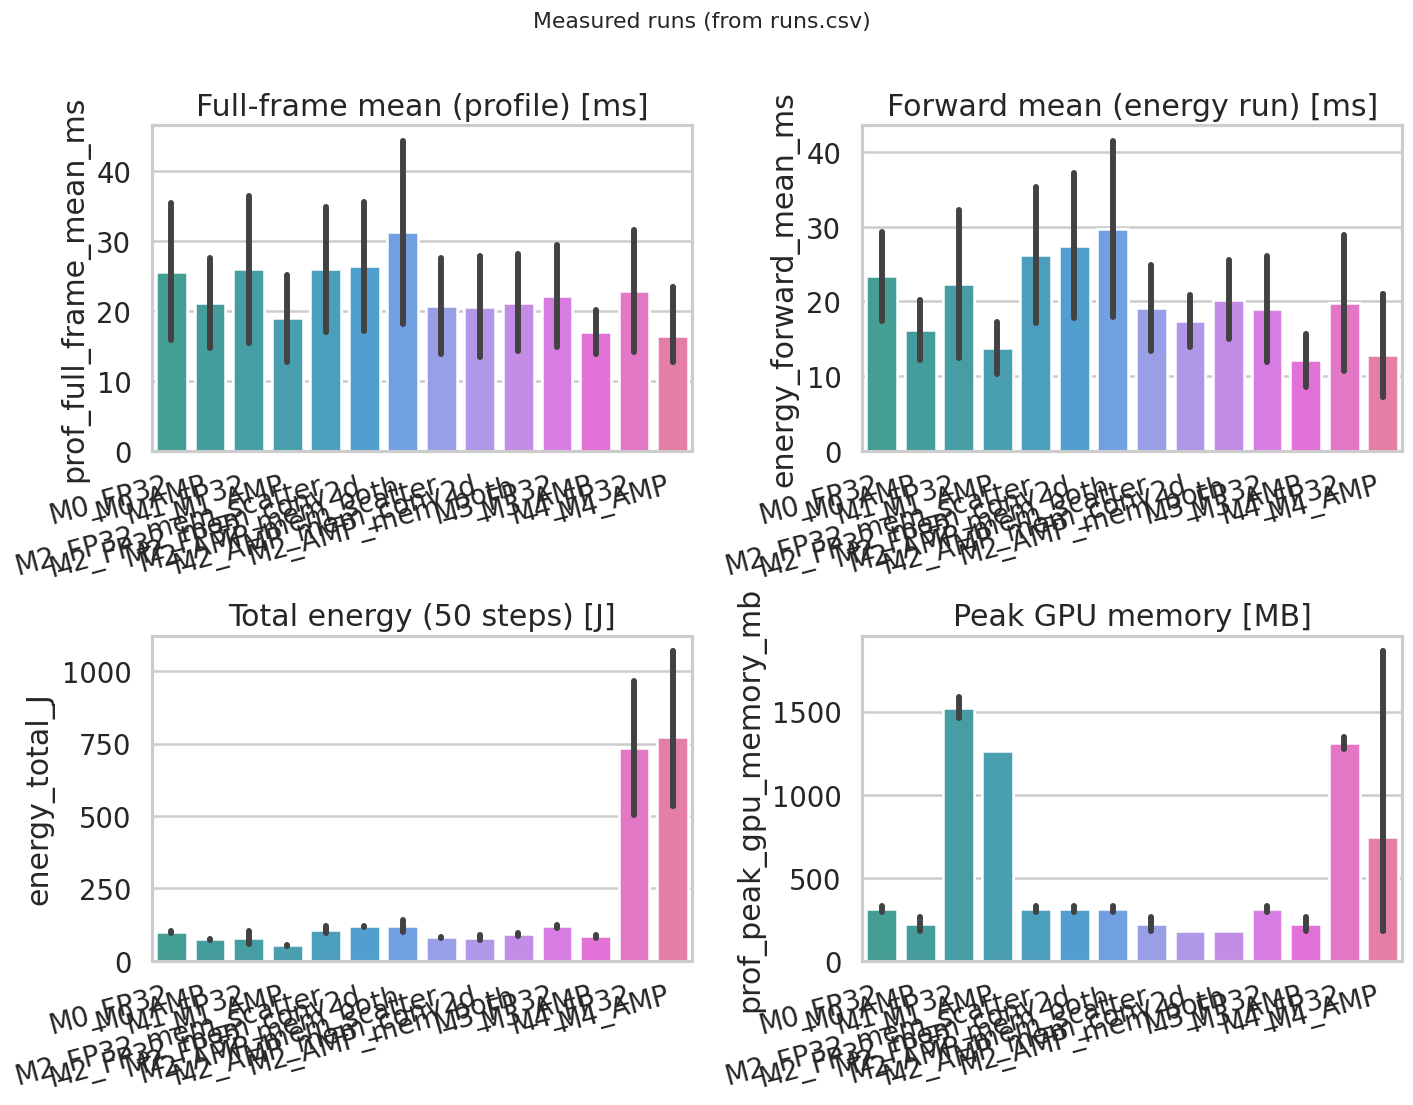

In [8]:
def to_float(s):
    if pd.isna(s) or s == "":
        return np.nan
    try:
        return float(s)
    except (TypeError, ValueError):
        return np.nan

if not runs.empty:
    plot_df = runs.copy()
    plot_df["label"] = plot_df["variant_name"].replace(
        {
            "baseline_fp32": "M1 FP32",
            "fp16_amp": "M1 AMP",
            "torch_compile_fp32": "M2 FP32",
        }
    )
    for c in [
        "prof_full_frame_mean_ms",
        "prof_forward_mean_ms",
        "energy_forward_mean_ms",
        "energy_total_J",
        "energy_mean_power_W",
        "prof_peak_gpu_memory_mb",
    ]:
        if c in plot_df.columns:
            plot_df[c] = plot_df[c].map(to_float)

    metrics = [
        ("prof_full_frame_mean_ms", "Full-frame mean (profile) [ms]"),
        ("energy_forward_mean_ms", "Forward mean (energy run) [ms]"),
        ("energy_total_J", "Total energy (50 steps) [J]"),
        ("prof_peak_gpu_memory_mb", "Peak GPU memory [MB]"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.ravel()
    for ax, (col, title) in zip(axes, metrics):
        if col not in plot_df.columns:
            ax.set_visible(False)
            continue
        sub = plot_df[["label", col]].dropna(subset=[col])
        if sub.empty:
            ax.text(0.5, 0.5, "no data", ha="center")
            continue
        order = sub["label"].tolist()
        sns.barplot(data=sub, x="label", y=col, ax=ax, order=order, palette="husl")
        ax.set_title(title)
        ax.set_xlabel("")
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha="right")
    plt.suptitle("Measured runs (from runs.csv)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Skip bar charts: no runs.csv")

## 5. Latency breakdown (stacked, profile stages)

Per run: dataloader, H2D, forward, postprocess (mean ms).

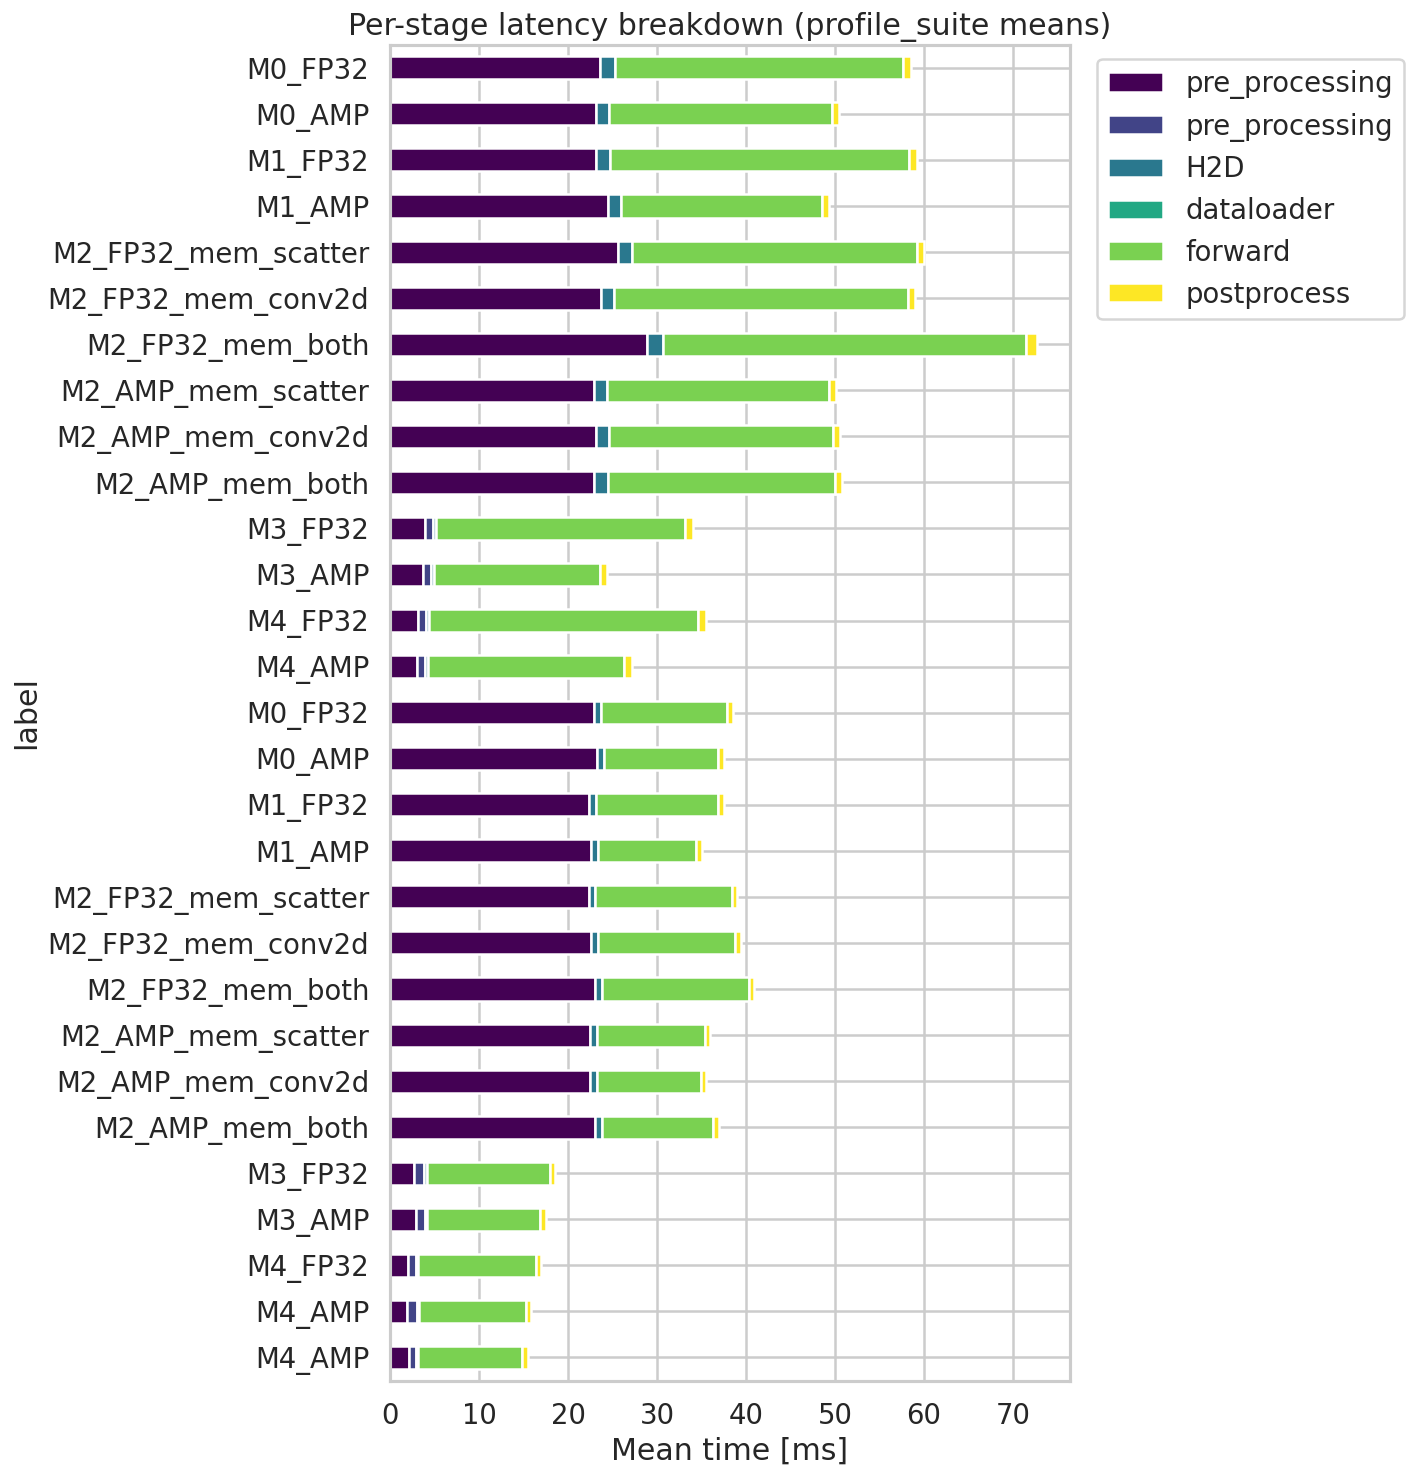

In [9]:
# Horizontal stacked bars: one row per experiment, all profile_suite stages.
import sys

_TOOLS = DATA_DIR.resolve().parent.parent / "OpenPCDet" / "tools"
if _TOOLS.is_dir() and str(_TOOLS) not in sys.path:
    sys.path.insert(0, str(_TOOLS))
from collect_research_metrics import _parse_profile_summary  # noqa: E402

STAGE_SPEC = [
    # ("prof_read_points_mean_ms", "read_points"),
    ("prof_pre_processing_mean_ms", "pre_processing"),
    ("prof_cpu_prepare_mean_ms", "pre_processing"),
    ("prof_data_to_gpu_pts_mean_ms", "H2D"),
    # ("prof_h2d_voxel_tail_mean_ms", "h2d (load rest)"),
    ("prof_dataloader_mean_ms", "dataloader"),
    # ("prof_h2d_mean_ms", "h2d"),
    ("prof_forward_mean_ms", "forward"),
    ("prof_postprocess_mean_ms", "postprocess"),
]


def enrich_runs_from_profile_summaries(runs_df: pd.DataFrame) -> pd.DataFrame:
    """Fill prof_* stage columns from profile_output_dir/profile_summary.txt when CSV cells are empty."""
    if runs_df.empty or "profile_output_dir" not in runs_df.columns:
        return runs_df
    out = runs_df.copy()
    for i in out.index:
        pdir = out.at[i, "profile_output_dir"]
        if not (isinstance(pdir, str) and pdir.strip()):
            continue
        summary_path = Path(pdir) / "profile_summary.txt"
        if not summary_path.is_file():
            continue
        try:
            parsed = _parse_profile_summary(summary_path.read_text(encoding="utf-8", errors="replace"))
        except OSError:
            continue
        for k, v in parsed.items():
            if k.startswith("_") or not k.startswith("prof_"):
                continue
            if k not in out.columns:
                out[k] = pd.Series(np.nan, index=out.index, dtype=float)
            cur = out.at[i, k]
            empty = pd.isna(cur) or (isinstance(cur, str) and not str(cur).strip())
            if not empty or v == "":
                continue
            try:
                out.at[i, k] = float(v)
            except (TypeError, ValueError):
                pass
    return out


runs_stages = enrich_runs_from_profile_summaries(runs)
if runs_stages.empty:
    print("Skip breakdown: runs is empty")
elif "variant_name" not in runs_stages.columns:
    print("Skip breakdown: need variant_name column")
elif "prof_forward_mean_ms" not in runs_stages.columns:
    print("Skip breakdown: need prof_forward_mean_ms")
else:
    br = runs_stages.copy()
    for col, _ in STAGE_SPEC:
        if col not in br.columns:
            br[col] = np.nan

    br["label"] = br["variant_name"].replace(
        {
            "baseline_fp32": "M1 FP32",
            "fp16_amp": "M1 AMP",
            "torch_compile_fp32": "M2 FP32",
        }
    )

    if (
        "exp" in globals()
        and isinstance(exp, pd.DataFrame)
        and not exp.empty
        and "variant_name" in exp.columns
    ):
        order = exp["variant_name"].astype(str).tolist()
        rank = {v: i for i, v in enumerate(order)}
        br["_rk"] = br["variant_name"].astype(str).map(rank)
        br = br.sort_values("_rk", kind="mergesort", na_position="last")
        br = br.drop(columns=["_rk"], errors="ignore")

    stage_cols = [c for c, _ in STAGE_SPEC]
    plot_st = br.set_index("label")[stage_cols].apply(
        lambda s: pd.to_numeric(s, errors="coerce").fillna(0.0)
    )
    plot_st.columns = [lab for _, lab in STAGE_SPEC]
    plot_st = plot_st.iloc[::-1]

    n = len(plot_st)
    fig_h = max(5.0, 0.36 * n + 2.0)
    plot_st.plot(kind="barh", stacked=True, figsize=(12, fig_h), colormap="viridis")
    plt.xlabel("Mean time [ms]")
    plt.title("Per-stage latency breakdown (profile_suite means)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 6. Energy–latency scatter (Pareto-style)

X: forward latency (energy run); Y: samples/J (higher is better). Bubble size ∝ throughput optional.

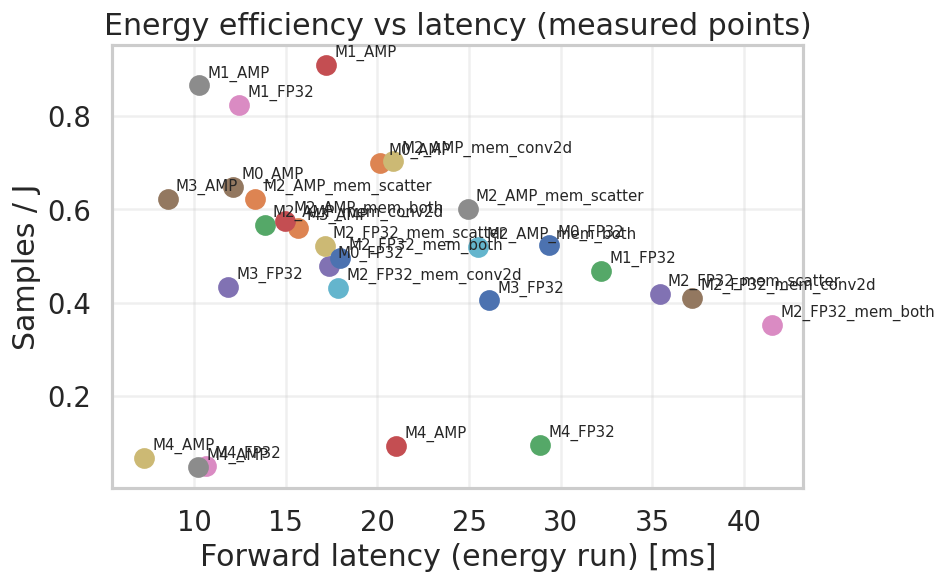

In [10]:
if not runs.empty and "energy_forward_mean_ms" in runs.columns and "energy_samples_per_J" in runs.columns:
    sc = runs.copy()
    sc["energy_forward_mean_ms"] = sc["energy_forward_mean_ms"].map(to_float)
    sc["energy_samples_per_J"] = sc["energy_samples_per_J"].map(to_float)
    sc["label"] = sc["variant_name"].replace(
        {
            "baseline_fp32": "M1 FP32",
            "fp16_amp": "M1 AMP",
            "torch_compile_fp32": "M2 FP32",
        }
    )
    sc = sc.dropna(subset=["energy_forward_mean_ms", "energy_samples_per_J"])
    if not sc.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        for _, r in sc.iterrows():
            ax.scatter(
                r["energy_forward_mean_ms"],
                r["energy_samples_per_J"],
                s=120,
                label=r["label"],
            )
            ax.annotate(r["label"], (r["energy_forward_mean_ms"], r["energy_samples_per_J"]), fontsize=9, xytext=(5, 5), textcoords="offset points")
        ax.set_xlabel("Forward latency (energy run) [ms]")
        ax.set_ylabel("Samples / J")
        ax.set_title("Energy efficiency vs latency (measured points)")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No numeric scatter data")
else:
    print("Skip scatter: missing columns")

## 7. Summary table for report (LaTeX-friendly)

Design grid + merge status with measured columns where available.

In [11]:
summary = exp[["cell_id", "model_variant", "precision_mode", "variant_name", "status"]].copy()
if not runs.empty:
    runs_m = runs.copy()
    runs_m["matrix_variant"] = runs_m["variant_name"].map(LEGACY_TO_MATRIX_VARIANT).fillna(runs_m["variant_name"])
    metric_cols = [
        c
        for c in [
            "map_car_r11",
            "kitti_car_3d_easy_r40",
            "kitti_car_3d_moderate_r40",
            "kitti_car_3d_hard_r40",
            "prof_full_frame_mean_ms",
            "energy_forward_mean_ms",
            "energy_total_J",
            "energy_samples_per_J",
            "prof_peak_gpu_memory_mb",
        ]
        if c in runs_m.columns
    ]
    rmini = runs_m[["matrix_variant"] + metric_cols]
    summary = summary.merge(rmini, left_on="variant_name", right_on="matrix_variant", how="left")
display(summary)
out_csv = DATA_DIR / "research_summary_table.csv"
summary.to_csv(out_csv, index=False)
print("Wrote", out_csv)

NameError: name 'exp' is not defined

## 8. Optional: per-step latency distributions

If `profile_latency_per_step_csv` paths exist, plot one forward-time histogram per variant in **stacked rows** (shared x-axis) for vertical comparison.

In [12]:
if not runs.empty and "profile_latency_per_step_csv" in runs.columns:
    series_rows = []
    for _, r in runs.iterrows():
        p = Path(str(r["profile_latency_per_step_csv"])).expanduser()
        if not p.is_file():
            continue
        step = pd.read_csv(p)
        if "forward" not in step.columns:
            continue
        lab = LEGACY_TO_MATRIX_VARIANT.get(r["variant_name"], r["variant_name"])
        series_rows.append((str(lab), step["forward"].dropna()))

    if not series_rows:
        print("Skip histograms (no valid profile_latency_per_step_csv)")
    else:
        n = len(series_rows)
        fig_h = max(2.8 * n, 4.0)
        fig, axes = plt.subplots(n, 1, figsize=(9, fig_h), sharex=True, squeeze=False)
        axes = axes.ravel()
        for ax, (lab, fwd) in zip(axes, series_rows):
            ax.hist(fwd, bins=30, alpha=0.75, color="steelblue", density=True)
            ax.set_ylabel("Density")
            ax.set_title(lab, loc="left", fontsize=10)
        axes[-1].set_xlabel("Forward [ms] (per step)")
        fig.suptitle("Forward latency distribution (profile_suite)", y=1.002)
        plt.tight_layout()
        plt.show()
else:
    print("Skip histograms")

Skip histograms (no valid profile_latency_per_step_csv)
